In [1]:
from magma_rsam import RSAM, PlotRsam
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import pandas as pd

In [2]:
start_date='2024-01-01'
end_date='2024-07-31'
station="KLGN"
channel="EHZ"

In [3]:
rsam = RSAM(
    seismic_dir="G:\\Output\\Converted\\SDS",
    station=station,
    channel=channel,
    start_date=start_date,
    end_date=end_date,
)

In [4]:
rsam.apply_filter(freq_min=5.0, freq_max=18.0)

ℹ️ Filter is on.


In [5]:
rsam.run()

✅ 2024-01-01 :: File RSAM for VG.KLGN.00.EHZ : D:\Project\magma-rsam\output\rsam\VG.KLGN.00.EHZ\filtered_5.0_18.0\10min\2024-01-01.csv
✅ 2024-01-02 :: File RSAM for VG.KLGN.00.EHZ : D:\Project\magma-rsam\output\rsam\VG.KLGN.00.EHZ\filtered_5.0_18.0\10min\2024-01-02.csv
✅ 2024-01-03 :: File RSAM for VG.KLGN.00.EHZ : D:\Project\magma-rsam\output\rsam\VG.KLGN.00.EHZ\filtered_5.0_18.0\10min\2024-01-03.csv
✅ 2024-01-04 :: File RSAM for VG.KLGN.00.EHZ : D:\Project\magma-rsam\output\rsam\VG.KLGN.00.EHZ\filtered_5.0_18.0\10min\2024-01-04.csv
✅ 2024-01-05 :: File RSAM for VG.KLGN.00.EHZ : D:\Project\magma-rsam\output\rsam\VG.KLGN.00.EHZ\filtered_5.0_18.0\10min\2024-01-05.csv
✅ 2024-01-06 :: File RSAM for VG.KLGN.00.EHZ : D:\Project\magma-rsam\output\rsam\VG.KLGN.00.EHZ\filtered_5.0_18.0\10min\2024-01-06.csv
✅ 2024-01-07 :: File RSAM for VG.KLGN.00.EHZ : D:\Project\magma-rsam\output\rsam\VG.KLGN.00.EHZ\filtered_5.0_18.0\10min\2024-01-07.csv
✅ 2024-01-08 :: File RSAM for VG.KLGN.00.EHZ : D:\Proje

In [6]:
plot_rsam = PlotRsam(
    station=station,
    channel=channel,
    start_date=start_date,
    end_date=end_date,
)

ℹ️ Start Date: 2024-01-01
ℹ️ End Date: 2024-07-31
ℹ️ Station: KLGN
ℹ️ Channel: EHZ
ℹ️ Network: VG
ℹ️ Location: 00
ℹ️ Resample: 10min


In [7]:
plot_rsam.with_filter(freq_min=5.0, freq_max=18.0)

In [8]:
plot_rsam.filtered_dir

'D:\\Project\\magma-rsam\\output\\rsam\\VG.KLGN.00.EHZ\\filtered_5.0_18.0'

✅ Combined CSV saved to : D:\Project\magma-rsam\output\rsam\VG.KLGN.00.EHZ\filtered_5.0_18.0\combined_VG.KLGN.00.EHZ_2024-01-01-2024-07-31_5.0-18.0Hz_10min.csv
⬆️ Max Amplitude: 6640.288334562655
⬇️ Min Amplitude: 4.078486946807469e-12
📈 RSAM Figure saved to : D:\Project\magma-rsam\output\figures\rsam\VG.KLGN.00.EHZ_2024-01-01-2024-07-31_5.0-18.0Hz_10min.png


,min,mean,max,median,std,mean_1d,median_1d
datetime,,,,,,,
2024-01-01 00:00:00,0.000530,45.315720,15123.640733,17.365915,184.964438,45.195549,21.765788
2024-01-01 00:10:00,0.000272,16.902838,1652.922162,11.889894,32.201628,45.231294,21.783147
2024-01-01 00:20:00,0.000035,21.958556,2354.300579,12.493340,54.701710,45.268482,21.800506
2024-01-01 00:30:00,0.000148,19.609601,3813.167242,9.167464,65.697402,45.132479,22.114690
2024-01-01 00:40:00,0.000454,22.388385,311.872251,16.890159,20.019834,45.001294,21.800506
...,...,...,...,...,...,...,...
2024-07-31 22:50:00,0.000242,55.005683,747.265142,42.708893,49.888712,38.234255,25.839539
2024-07-31 23:00:00,0.000177,62.940939,680.590833,47.919835,57.387233,38.344547,26.223426
2024-07-31 23:10:00,0.001388,57.301088,613.481557,43.652230,52.815201,38.360312,25.839539


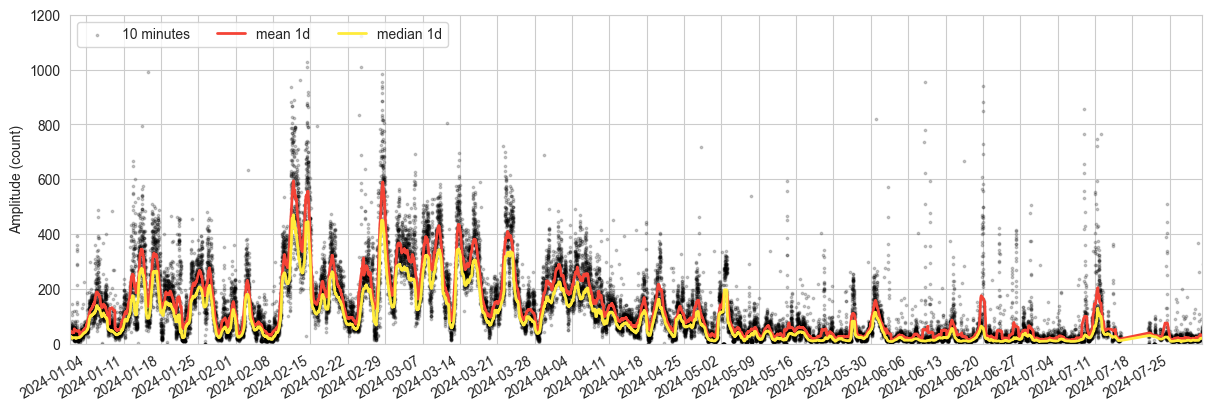

In [9]:
plot_rsam.set_y_lim(y_min=0, y_max=1200).run(
    datetime_interval=7,
)

In [ ]:
df = plot_rsam.df

In [ ]:
datetime_index: pd.DatetimeIndex = pd.date_range(start=start_date, end=end_date, freq='10min')

In [ ]:
df = df.reindex(datetime_index)

In [ ]:
df['mean_24h'] = df['mean'].rolling('24h', center=True).median()

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(12, 4),
                        layout="constrained", sharex=True)

axs.scatter(df.index, df['mean'], c='k', alpha=0.2, s=3, label='10 minutes')
axs.plot(df.index, df['mean_24h'], c='red', label='median 1d', alpha=1, lw=2)
axs.set_ylabel('Amplitude (count)')

axs.xaxis.set_major_locator(mdates.DayLocator(interval=7))
axs.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axs.set_ylim(-150, 15000)
# axs.set_yscale('log')
axs.set_xlim(datetime.strptime(start_date, '%Y-%m-%d'), datetime.strptime(end_date, '%Y-%m-%d'))

# axs.axvspan("2024-04-16", "2024-04-19", alpha=0.2,
#              color='orange', label='Continuous Eruption')
# 
# axs.axvline(datetime.strptime("2024-04-16", '%Y-%m-%d'),
#             color='red', label='First Eruption')

for label in axs.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
    
axs.legend(loc='upper left', fontsize='10', ncol=4)

fig.savefig(f"rsam_awu_{station}_not_filtered.png")
# fig.savefig(f'rsam_awu_{station}_filtered_5-18Hz.png')

In [ ]:
continuous_events = [
    {
        'name': 'Eruption',
        'dates': ['2024-04-16', '2024-04-16'],
        'color': 'orange'
    }
]

In [ ]:
events = [
    {
        'name': 'Level II',
        'dates': ['2024-04-16', '2024-04-18'],
        'color': 'orange'
    }
]

In [ ]:
continuous_events = continuous_events + events

In [ ]:
continuous_events